# Sample-Specific Variance in Differential Analysis

This tutorial demonstrates how to perform differential analysis in single-cell data while accounting for biological variance between samples. We'll explore:

1. Why sample variance matters in differential analysis
2. How to run Kompot analyses with and without sample variance
3. How to visualize and interpret the results
4. How sample variance affects statistical significance

## Introduction to Sample Variance

When analyzing single-cell data across multiple samples (e.g., different patients, mice, or experimental batches), it's crucial to account for sample-specific effects. The variability between samples can often be much larger than the variability between conditions, leading to inflated significance estimates if not properly accounted for.

Kompot provides built-in support for sample variance estimation, which:

- Trains estimators for each sample separately
- Computes variance across samples within each condition
- Adjusts statistical significance estimates based on sample variability
- Provides more conservative and robust differential results

## Setup and Data Loading

First, let's load the necessary libraries and set up our environment:

In [1]:
import anndata as ad
import matplotlib.pyplot as plt

# Import necessary libraries
import numpy as np
import palantir
import pandas as pd
import scanpy as sc
import seaborn as sns

import kompot

# Set plotting style
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["image.cmap"] = "Spectral_r"

/Users/dotto/micromamba/envs/kompot_v2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Now let's define the parameters for our analysis. In this tutorial we're using a bone marrow dataset with cells from young and old individuals. We'll compare these two conditions while accounting for biological variation across individual samples.

In [2]:
# Data path - replace with your own AnnData file path
# For reproducibility, you can download the example file from: ...
DATA_PATH = "../data/processed_filtered_HSPCandMature_withcorrection_withregression_postcelltype.h5ad"

# Analysis parameters
SAMPLE_COLUMN = "Replicate"  # Column in adata.obs with sample labels
GROUPING_COLUMN = "Age"  # Column in adata.obs with condition labels
CONDITIONS = ["Young", "Old"]  # Conditions to compare (first is reference)
CELL_TYPE_COLUMN = "highres_celltype"  # Column in adata.obs with cell type annotations
DIMENSIONALITY_REDUCTION = (
    "DM_EigenVectors"  # Key in adata.obsm for cell state representation
)
LAYER_FOR_EXPRESSION = (
    "logged_counts"  # Layer in adata.layers for expression data (None uses adata.X)
)

In [3]:
adata = ad.read_h5ad(DATA_PATH)
adata

AnnData object with n_obs × n_vars = 8090 × 16285
    obs: 'Compartment', 'Replicate', 'Age', 'Sample', 'Info', 'batch', 'doublet_score', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'leiden', 'phenograph', 'highres_celltype', 'midres_celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Age_colors', 'Compartment_colors', 'DMEigenValues', 'Info_colors', 'README', 'Replicate_colors', 'Sample_colors', 'batch_colors', 'draw_graph', 'highres_celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'midres_celltype_colors', 'neighbors', 'pca', 'phase_colors', 'umap'
    obsm: 'AbCapture', 'DM_EigenVectors', 'HTO', 'X_draw_graph_fa', 'X_pca', 'X_pca_harmony', 'X_pca_noregression',

## Exploring the Data

Before running any analysis, it's important to understand the structure of your data. Let's visualize the data to understand:

1. **Cell Type Distribution**: How many cells of each type are in our dataset?
2. **Condition Distribution**: How balanced are our conditions (Young to. Old)?
3. **Cell Type by Condition**: Are certain cell types biased toward particular conditions?

These exploratory analyses will help us interpret the differential results later.

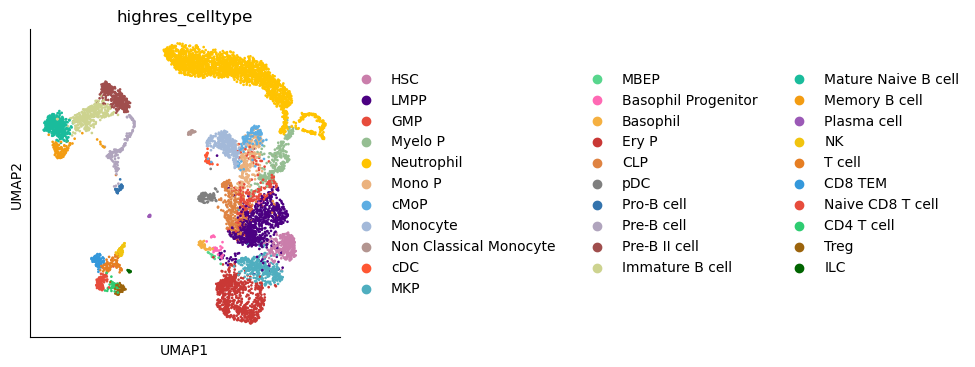

In [4]:
sc.pl.umap(adata, color=CELL_TYPE_COLUMN)

In [5]:
palantir.utils.run_diffusion_maps(adata, pca_key="X_pca_harmony", n_components=40);

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Standard Differential Analysis (Without Sample Variance)

First, we'll demonstrate the standard differential analysis approach that doesn't account for sample-specific variance. This is the typical approach used when either there's only one sample per condition, or when you're intentionally ignoring sample-specific effects.

### Step 1: Differential Abundance Analysis

We'll start by computing differential abundance between young and old conditions. This analyzes changes in the cell state distribution without considering sample-specific effects:

In [6]:
# First, let's compute differential abundance between conditions
da_results = kompot.compute_differential_abundance(
    adata,  # AnnData object
    groupby=GROUPING_COLUMN,  # Column with condition labels
    condition1=CONDITIONS[0],  # Reference condition
    condition2=CONDITIONS[1],  # Comparison condition
    obsm_key=DIMENSIONALITY_REDUCTION,  # Cell state representation
)

[2025-03-24 20:31:01,264] [INFO    ] Condition 1 (Young): 2,917 cells
[2025-03-24 20:31:01,268] [INFO    ] Condition 2 (Old): 3,116 cells
[2025-03-24 20:31:01,275] [INFO    ] Fitting density estimator for condition 1...
[2025-03-24 20:31:13,606] [INFO    ] Fitting density estimator for condition 2...
[2025-03-24 20:31:18,221] [WARNING ] The normalization is only effective if the density was trained with d_method="fractal".
[2025-03-24 20:31:18,705] [WARNING ] The normalization is only effective if the density was trained with d_method="fractal".
[2025-03-24 20:31:21,362] [INFO    ] This run will have `run_id=0`.


### Step 2: Differential Expression Analysis

Next, we'll compute differential expression between the conditions using the same approach without sample variance. This identifies genes that change between conditions:

In [7]:
# Now, compute differential expression between the conditions
de_results = kompot.compute_differential_expression(
    adata,  # AnnData object
    groupby=GROUPING_COLUMN,  # Column with condition labels
    condition1=CONDITIONS[0],  # Reference condition
    condition2=CONDITIONS[1],  # Comparison condition
    layer=LAYER_FOR_EXPRESSION,  # Expression data layer
    obsm_key=DIMENSIONALITY_REDUCTION,  # Cell state representation
    differential_abundance_key="kompot_da",  # DA results for weighted log-fold change (optional)
    batch_size=0,  # set to, e.g., 100 to batch cells and genes for lower memory demand
)

[2025-03-24 20:31:21,369] [INFO    ] Condition 1 (Young): 2,917 cells
[2025-03-24 20:31:21,369] [INFO    ] Condition 2 (Old): 3,116 cells
[2025-03-24 20:31:23,018] [INFO    ] Fitting expression estimator for condition 1...
[2025-03-24 20:31:24,763] [INFO    ] Fitting expression estimator for condition 2...
[2025-03-24 20:31:30,651] [INFO    ] Landmark storage skipped (store_landmarks=False). Compute with store_landmarks=True to enable landmark reuse.
[2025-03-24 20:31:48,093] [INFO    ] Computing Mahalanobis distances...
[2025-03-24 20:31:48,093] [INFO    ] Using 5,000 landmarks for Mahalanobis computation
[2025-03-24 20:31:55,570] [INFO    ] Computing Cholesky decomposition of covariance matrix
[2025-03-24 20:31:57,283] [INFO    ] This run will have `run_id=0`.


## Differential Analysis With Sample Variance

Now, we'll perform the same analyses while accounting for sample-specific variance. The key difference is including the `sample_col` parameter, which tells Kompot which column in `adata.obs` contains the sample identifiers.

### Step 1: Differential Abundance with Sample Variance

The first step is similar, but now we include the sample information:

In [8]:
# First, let's compute differential abundance between conditions
da_results = kompot.compute_differential_abundance(
    adata,  # AnnData object
    groupby=GROUPING_COLUMN,  # Column with condition labels
    condition1=CONDITIONS[0],  # Reference condition
    condition2=CONDITIONS[1],  # Comparison condition
    obsm_key=DIMENSIONALITY_REDUCTION,  # Cell state representation
    sample_col=SAMPLE_COLUMN,  # Sample labels
)

[2025-03-24 20:31:57,389] [INFO    ] Results with result_key='kompot_da' already exist in the dataset. Previous run was at 2025-03-24T20:31:21.362294 comparing Young to Old. Fields that will be overwritten: obs:kompot_da_log_fold_change_Young_to_Old, obs:kompot_da_log_density_Young. Note: Only fields NOT affected by sample variance (like log_fold_change, log_density) will be overwritten since they don't use the sample variance suffix. These results will likely be identical if other parameters haven't changed. This is a partial rerun with sample variance added to a previous analysis with matching parameters. Set overwrite=False to prevent overwriting or overwrite=True to silence this message.
[2025-03-24 20:31:57,390] [INFO    ] Condition 1 (Young): 2,917 cells
[2025-03-24 20:31:57,390] [INFO    ] Condition 2 (Old): 3,116 cells
[2025-03-24 20:31:57,392] [INFO    ] Using sample column 'Replicate' for sample variance estimation
[2025-03-24 20:31:57,393] [INFO    ] Found 3 unique sample(s)

### Step 2: Differential Expression with Sample Variance

For differential expression analysis with sample variance, memory usage can be much higher because Kompot computes a gene-specific covariance matrix for each gene. To manage memory usage, we'll analyze only the top 100 genes (by Mahalanobis distance) from our previous analysis.

In [9]:
# Now, compute differential expression between the conditions
topn = 200 # use a subset of genes to reduce resource demand
genes = adata.var.sort_values("kompot_de_mahalanobis_Young_to_Old", ascending=False).head(topn).index
de_results = kompot.compute_differential_expression(
    adata,  # AnnData object
    groupby=GROUPING_COLUMN,  # Column with condition labels
    condition1=CONDITIONS[0],  # Reference condition
    condition2=CONDITIONS[1],  # Comparison condition
    layer=LAYER_FOR_EXPRESSION,  # Expression data layer
    obsm_key=DIMENSIONALITY_REDUCTION,  # Cell state representation
    differential_abundance_key="kompot_da",  # DA results for weighted log-fold change (optional)
    batch_size=0,  # set to, e.g., 100 to batch-process cells for lower memory demand
    store_arrays_on_disk=True, # stores covariance matrices on disk to process larger amounts of genes at once
    sample_col=SAMPLE_COLUMN,  # Sample labels
    genes=genes, # genes to be processed
)

[2025-03-24 20:32:29,232] [INFO    ] Differential expression results with result_key='kompot_de' already exist in the dataset. Previous run was at 2025-03-24T20:31:57.283201 comparing Young to Old. Fields that will be overwritten: var:kompot_de_mean_lfc_Young_to_Old, var:kompot_de_bidirectionality_Young_to_Old, layers:kompot_de_imputed_Young, layers:kompot_de_fold_change_Young_to_Old. Note: Only fields NOT affected by sample variance (like mean_log_fold_change, bidirectionality, imputed data, fold_change) will be overwritten since they don't use the sample variance suffix. These results will likely be identical if other parameters haven't changed. This is a partial rerun with sample variance added to a previous analysis with matching parameters. Set overwrite=False to prevent overwriting or overwrite=True to silence this message.
[2025-03-24 20:32:29,233] [INFO    ] Condition 1 (Young): 2,917 cells
[2025-03-24 20:32:29,233] [INFO    ] Condition 2 (Old): 3,116 cells
[2025-03-24 20:32:29

Computing Mahalanobis distances: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [06:49<00:00,  2.05s/it]

[2025-03-24 20:40:49,770] [INFO    ] Successfully computed Mahalanobis distances for 200 genes using gene-specific covariance


[2025-03-24 20:40:51,384] [INFO    ] This run will have `run_id=1`.
[2025-03-24 20:40:51,410] [INFO    ] Removed temporary storage directory /var/folders/h_/5f32jgps7yq4np44vpfbx4300000gn/T/kompot_arrays_cb05154b_360edl3r
[2025-03-24 20:40:51,443] [INFO    ] Removed temporary storage directory /var/folders/h_/5f32jgps7yq4np44vpfbx4300000gn/T/kompot_arrays_9e8cc70c_1e99oo9c


## Comparing Results: With vs. Without Sample Variance

Now let's compare the results from both approaches to understand how accounting for sample variance affects our differential analysis.

### Comparing Differential Abundance Results

First, let's visualize the differential abundance results on the UMAP embedding. We'll compare:
1. The direction of abundance changes 
2. The log fold changes in abundance
3. The statistical significance (z-scores) with and without sample variance

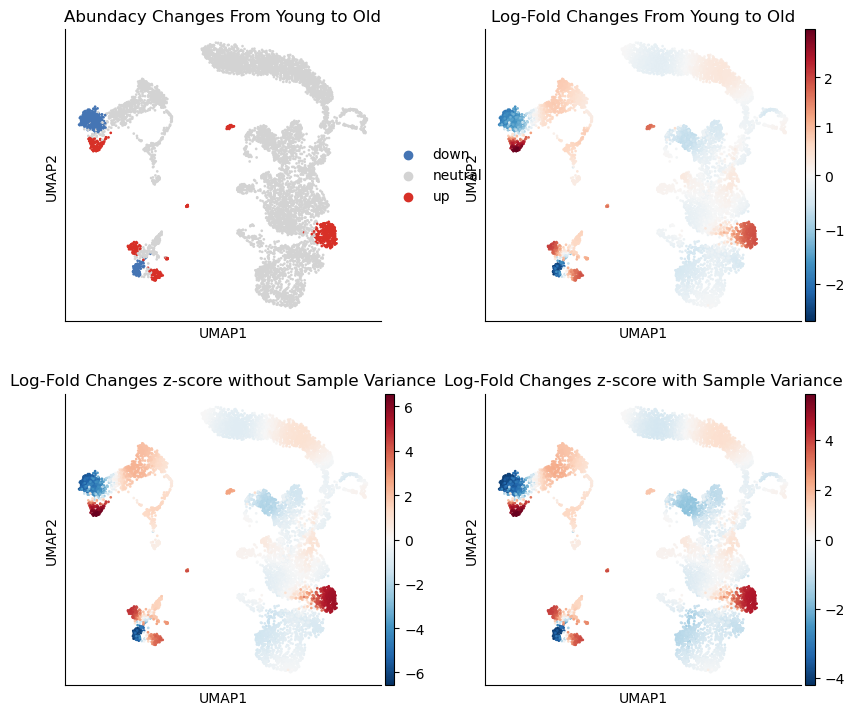

In [11]:
sc.pl.embedding(
    adata,
    "umap",
    color=[
        "kompot_da_log_fold_change_direction_Young_to_Old",
        "kompot_da_log_fold_change_Young_to_Old",
        "kompot_da_log_fold_change_zscore_Young_to_Old",
        "kompot_da_log_fold_change_zscore_Young_to_Old_sample_var",
    ],
    title=[
        "Abundacy Changes From Young to Old",
        "Log-Fold Changes From Young to Old",
        "Log-Fold Changes z-score without Sample Variance",
        "Log-Fold Changes z-score with Sample Variance",
    ],
    color_map="RdBu_r",
    vcenter=0,
    ncols=2,
)

### Volcano Plots for Differential Abundance

Volcano plots provide another way to visualize differential abundance results. They show the log fold change (effect size) on the x-axis and statistical significance on the y-axis. Points above the horizontal line and outside the vertical lines indicate statistically significant changes.

Let's first look at the standard analysis without sample variance. To specify the ploting function which data to use, we can either provide the `lfc_key` and `pval_key` columns with results written by the `compute_differential_abundance` function, or provide the `run_id` that specifies the differential abundance run based on the order they were executed. The first run has `rund_id=0`:

[2025-03-24 20:47:29,861] [INFO    ] Using inferred thresholds - lfc_threshold: 1.0, pval_threshold: 0.05


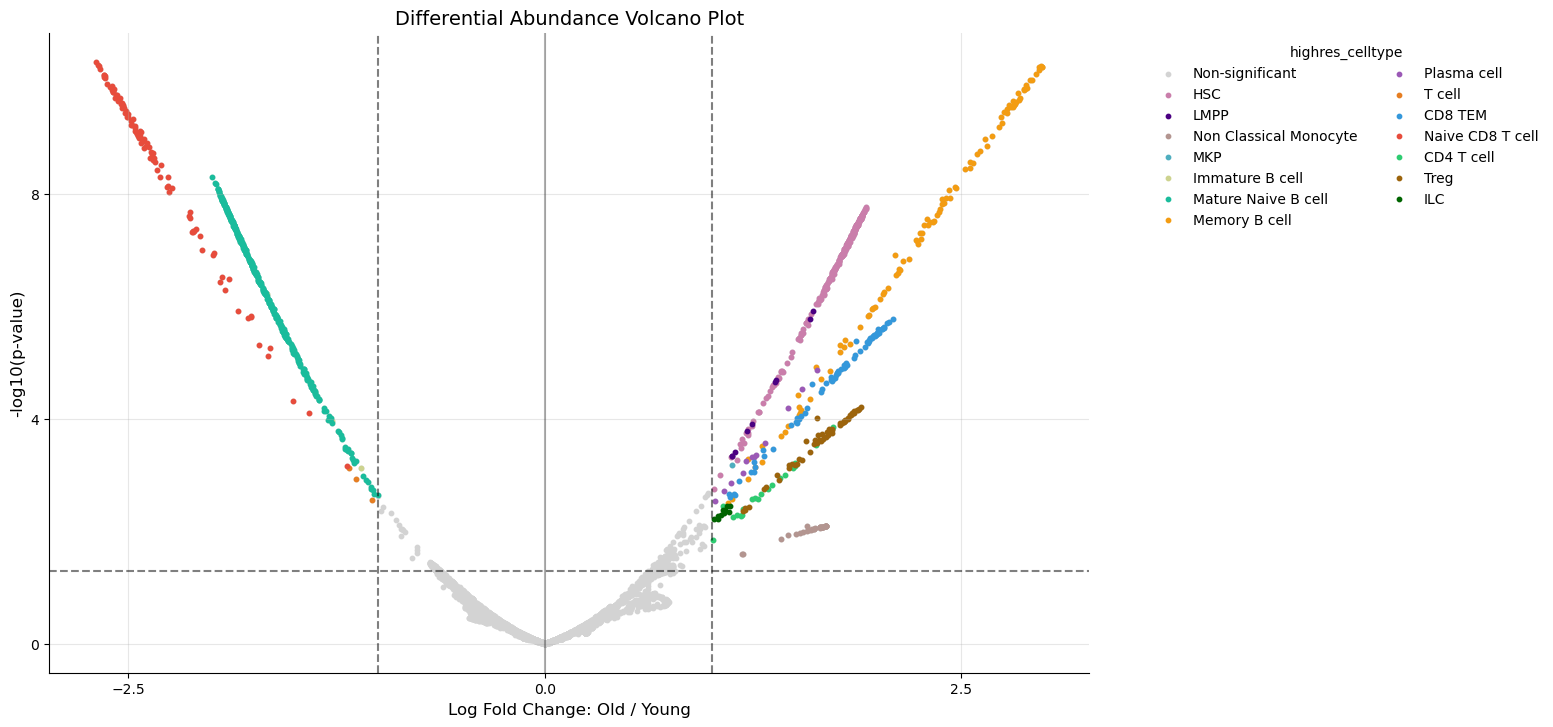

In [12]:
kompot.plot.volcano_da(adata, color=CELL_TYPE_COLUMN, run_id=0)

Now, let's look at the analysis with sample variance (`run_id=1`):

[2025-03-24 20:47:30,013] [INFO    ] Using inferred thresholds - lfc_threshold: 1.0, pval_threshold: 0.05


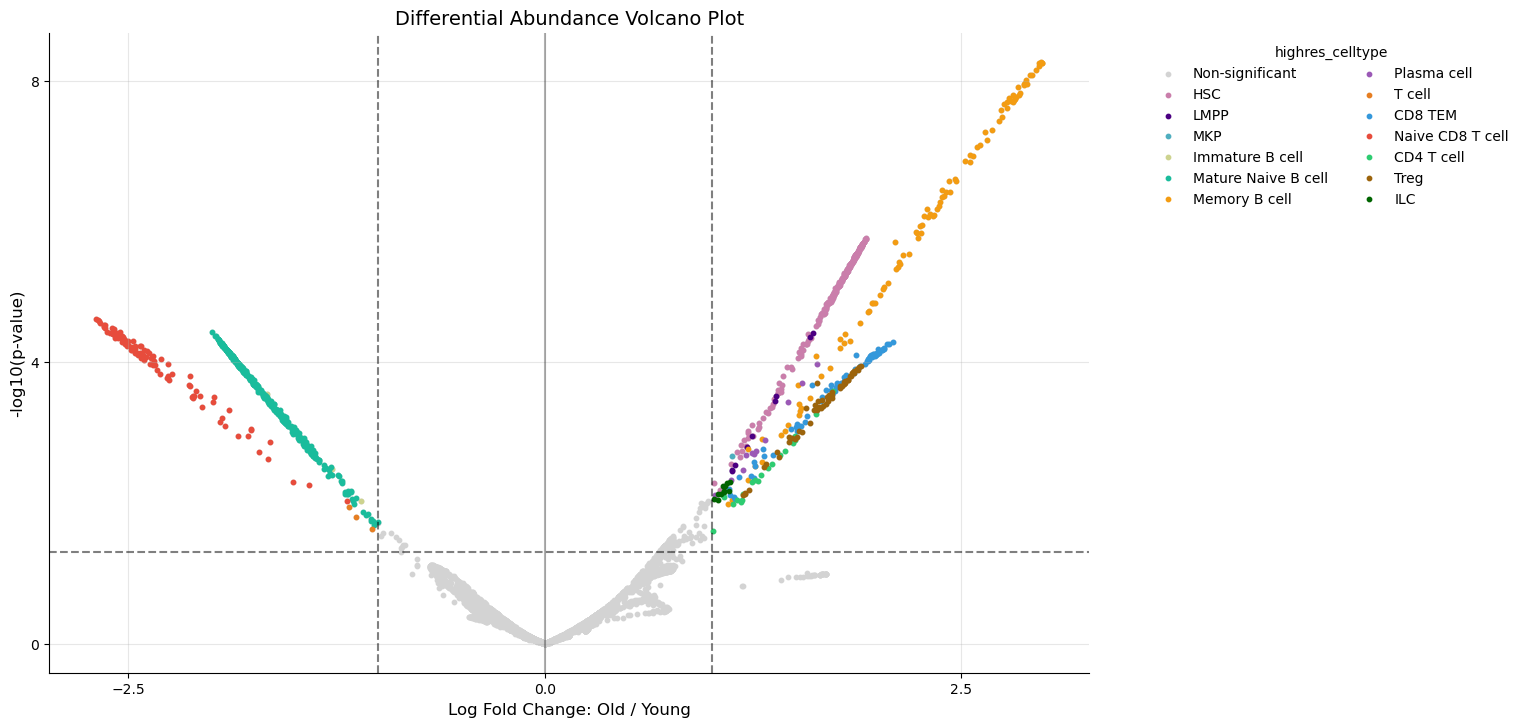

In [13]:
kompot.plot.volcano_da(adata, color=CELL_TYPE_COLUMN, run_id=1)

### Key Observations from Differential Abundance Analysis

Comparing the volcano plots with and without sample variance:

1. **Statistical significance thresholds**: P-values (y-axis) are generally lower when using sample variance, reflecting a more conservative statistical assessment.

2. **Cell type patterns**: Both plots show similar cell type-specific patterns of differential abundance, but the significance estimates differ.

3. **Effect sizes**: Log fold changes (x-axis) remain consistent between methods, as sample variance affects significance but not effect size estimation.

## Comparing Differential Expression Results

Now let's examine how sample variance affects differential gene expression analysis.

### Top Differentially Expressed Genes

First, let's examine the top differentially expressed genes identified in our standard analysis (without sample variance):

In [14]:
adata.var[
    ["kompot_de_weighted_lfc_Young_to_Old", "kompot_de_mahalanobis_Young_to_Old"]
].sort_values("kompot_de_mahalanobis_Young_to_Old", ascending=False).head(20)

,kompot_de_weighted_lfc_Young_to_Old,kompot_de_mahalanobis_Young_to_Old
H2-Q7,1.362024,71.513349
Cd74,0.538759,60.009648
H2-Aa,0.619222,59.363446
H2-Ab1,0.586454,57.802727
Igkc,0.090495,53.590103
H2-Eb1,0.552377,53.395852
AW112010,0.933069,53.380621
S100a9,-0.470677,48.752285
Ifitm3,0.563391,47.574401
S100a8,-0.469816,47.359853


### Volcano Plots for Differential Expression

Now, let's look at volcano plots for differential expression, first without sample variance (`run_id=0`):

[2025-03-24 20:47:30,157] [INFO    ] Using DE run 0: comparing Young to Old
[2025-03-24 20:47:30,157] [INFO    ] Using fields for DE plot - lfc_key: 'kompot_de_mean_lfc_Young_to_Old', score_key: 'kompot_de_mahalanobis_Young_to_Old'
[2025-03-24 20:47:30,165] [INFO    ] Highlighting top 100 genes by kompot_de_mahalanobis_Young_to_Old


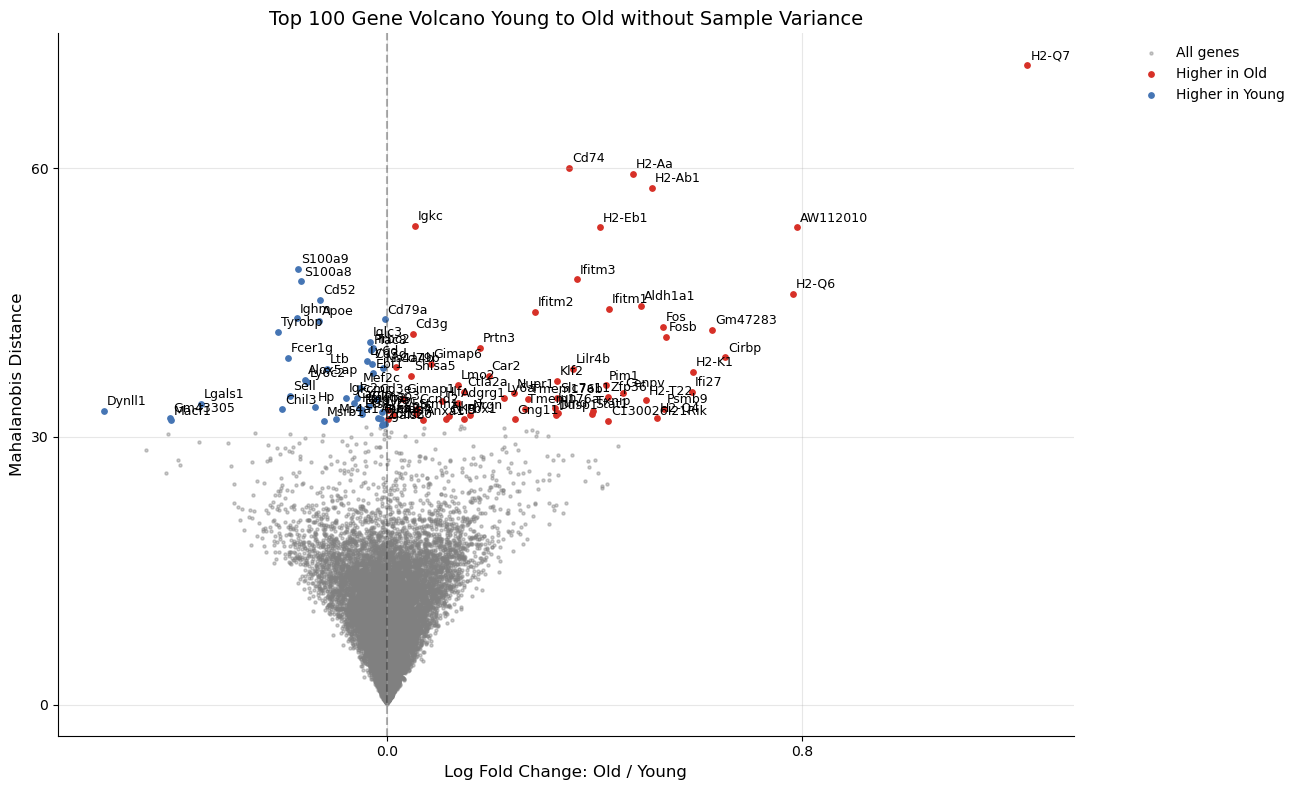

In [15]:
kompot.plot.volcano_de(
    adata,
    n_top_genes=100,
    run_id=0,
    title="Top 100 Gene Volcano Young to Old without Sample Variance",
)

And now with sample variance (remember we limited this analysis to only the top 100 genes). Note that some genes assert much lower significance (Mahalanobis distance) when accounting for sample variance:

[2025-03-24 20:47:30,348] [INFO    ] Using DE run 1: comparing Young to Old
[2025-03-24 20:47:30,348] [INFO    ] Using fields for DE plot - lfc_key: 'kompot_de_mean_lfc_Young_to_Old', score_key: 'kompot_de_mahalanobis_Young_to_Old_sample_var'
[2025-03-24 20:47:30,354] [INFO    ] Highlighting top 100 genes by kompot_de_mahalanobis_Young_to_Old_sample_var


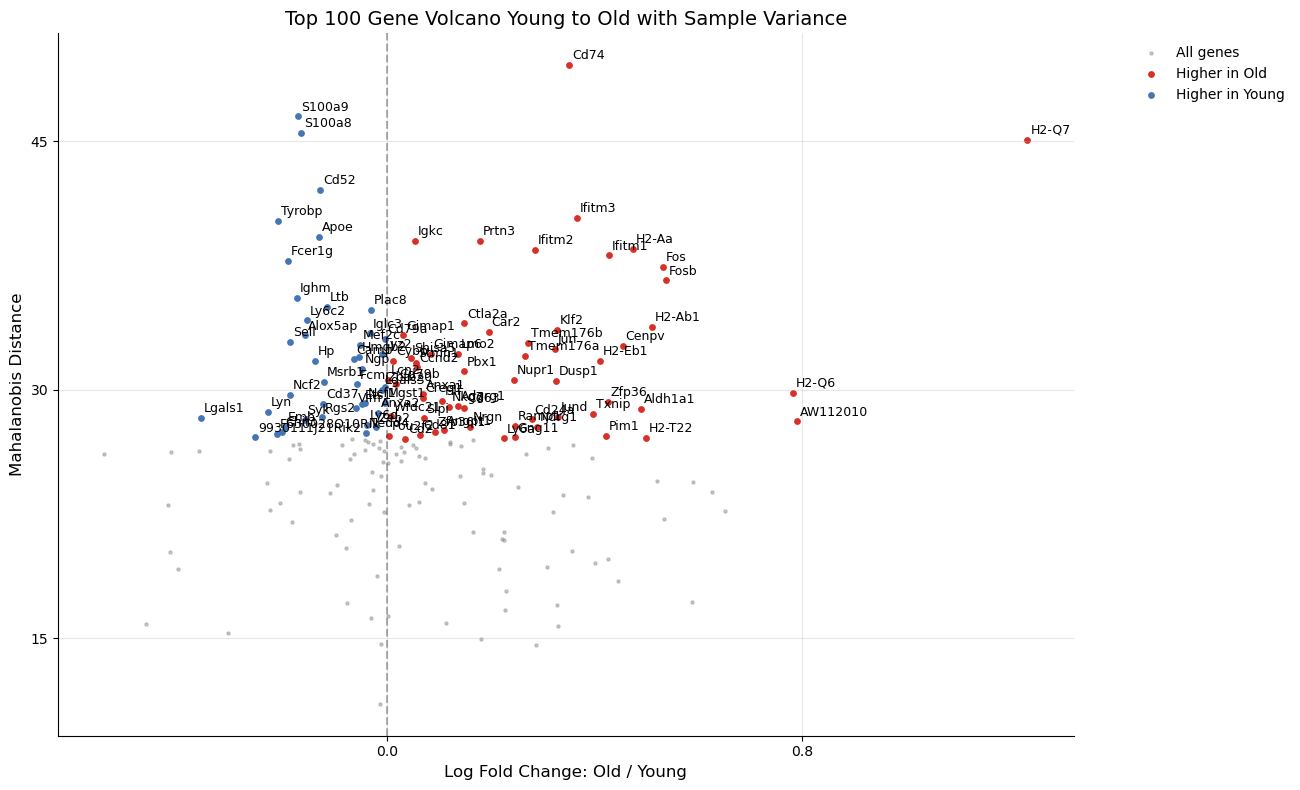

In [16]:
kompot.plot.volcano_de(
    adata,
    n_top_genes=100,
    run_id=1,
    title="Top 100 Gene Volcano Young to Old with Sample Variance",
)

### Heatmaps of Top Differentially Expressed Genes

Heatmaps provide a cell type-specific view of expression changes. These expression changes are just averages of the actual expression values per group and not a result of kompot. However, the gene ranking is done through the Mahalnobis distance computed by Kompot. Let's create heatmaps for the top genes identified with and without sample variance.

First, from the ranking without considering sample variance (`run_id=0`):

[2025-03-24 20:47:30,529] [INFO    ] Using DE run 0 for heatmap.
[2025-03-24 20:47:30,529] [INFO    ] Inferred score_key='kompot_de_mahalanobis_Young_to_Old' from run information
[2025-03-24 20:47:30,531] [INFO    ] Inferred condition_column='Age' from run information
[2025-03-24 20:47:30,531] [INFO    ] Inferred condition1='Young' from run information
[2025-03-24 20:47:30,532] [INFO    ] Inferred condition2='Old' from run information
[2025-03-24 20:47:30,532] [INFO    ] Inferred layer='logged_counts' from run information
[2025-03-24 20:47:30,532] [INFO    ] Creating split heatmap with 20 genes/features
[2025-03-24 20:47:30,532] [INFO    ] Using expression data from layer: 'logged_counts'
[2025-03-24 20:47:30,560] [INFO    ] Excluded 7 cells from groups: Plasma cell
[2025-03-24 20:47:30,563] [INFO    ] Applying gene-wise z-scoring (standard_scale='var')


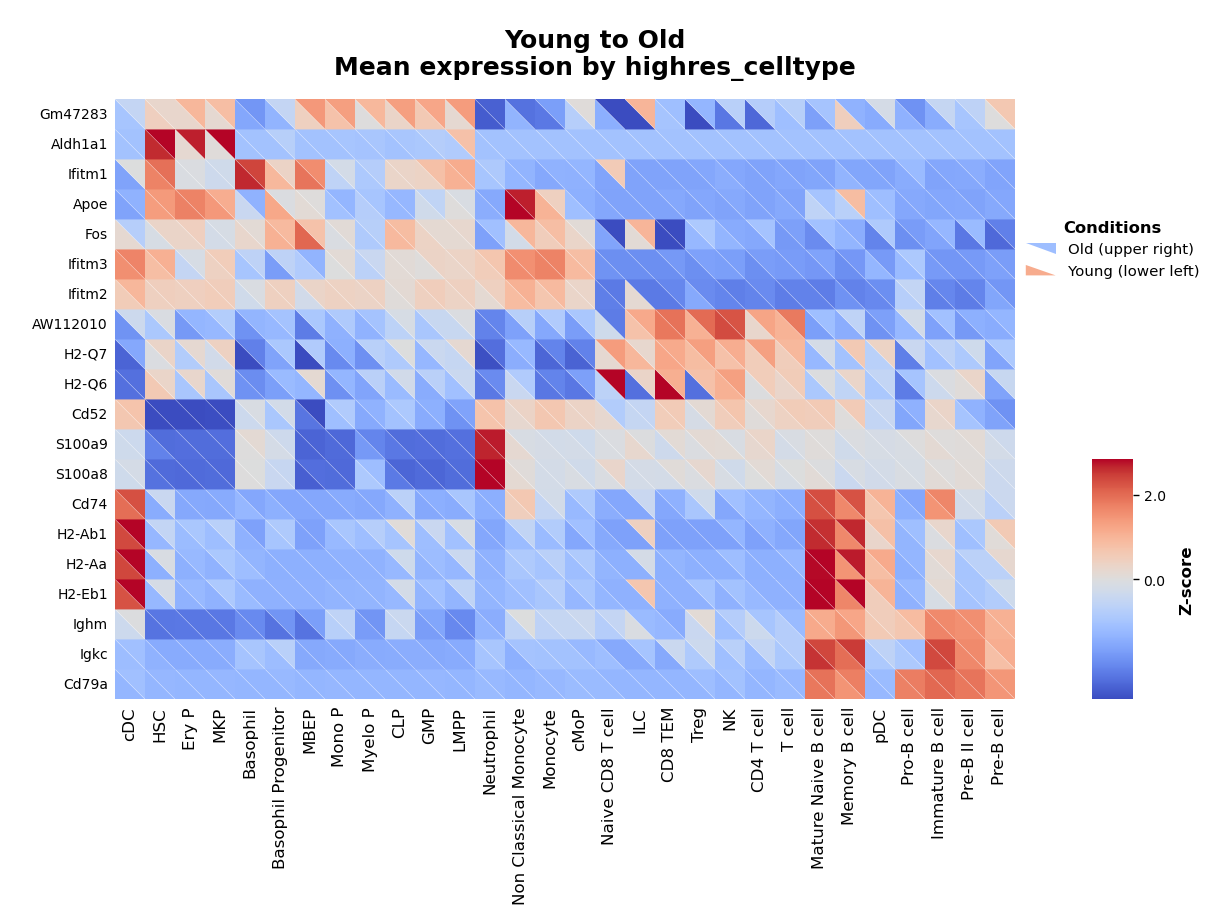

In [17]:
kompot.plot.heatmap(
    adata,
    n_top_genes=20,
    groupby=CELL_TYPE_COLUMN,
    exclude_groups="Plasma cell",
    run_id=0,
    vmin="p1",
    vmax="p99",
)

Now, showing the top 20 genes when ranking them considering sample variance (`run_id=1`):

Inspecting the worst performing genes by scoring under consideration of sample variance, we see considerable variability across the replicates, here comparing replicate 1 and 3:

[2025-03-24 20:47:31,132] [INFO    ] Inferred layer='logged_counts' from run information
[2025-03-24 20:47:31,132] [INFO    ] Creating split heatmap with 20 genes/features
[2025-03-24 20:47:31,133] [INFO    ] Using display names: 'Replicate 1' for condition1, 'Replicate 3' for condition2
[2025-03-24 20:47:31,133] [INFO    ] Using expression data from layer: 'logged_counts'
[2025-03-24 20:47:31,160] [INFO    ] Applying gene-wise z-scoring (standard_scale='var')


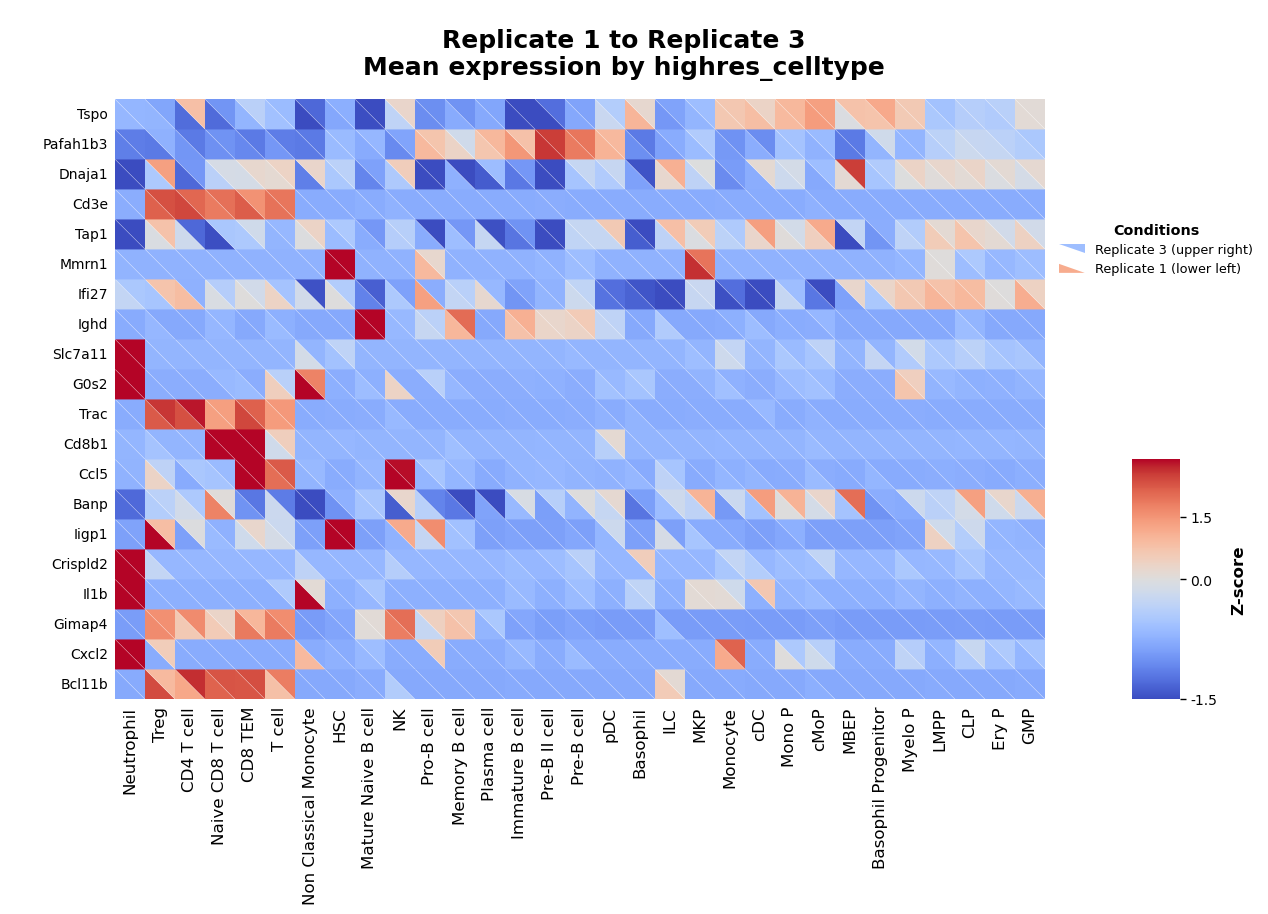

In [18]:
kompot.plot.heatmap(
    adata,
    genes=adata.var.sort_values(
        "kompot_de_mahalanobis_Young_to_Old_sample_var", ascending=False, na_position='first'
    ).tail(20).index,
    groupby=CELL_TYPE_COLUMN,
    condition_column=SAMPLE_COLUMN,
    condition1="1",
    condition1_name="Replicate 1",
    condition2="3",
    condition2_name="Replicate 3",
    vmin="p2",
    vmax="p98",
    cluster_rows=False,
)

### Detailed Expression Visualization

For specific genes of interest, we can create detailed visualizations that show:
1. Original expression
2. Imputed expression in each condition
3. Log fold change between conditions

Since these results are not effected by sample variance, we can let the plotting function pick the latest result.

Let's look at a T-cell marker gene (Cd3g):

[2025-03-24 20:47:31,604] [INFO    ] Using DE run 2: comparing Young to Old
[2025-03-24 20:47:31,605] [INFO    ] Using fields for gene expression plot - lfc_key: 'kompot_de_mean_lfc_Young_to_Old', score_key: 'kompot_de_mahalanobis_Young_to_Old_sample_var'
[2025-03-24 20:47:31,605] [INFO    ] Using layer 'logged_counts' inferred from run information
[2025-03-24 20:47:31,606] [INFO    ] Using condition1 imputed layer 'kompot_de_imputed_Young' for 'Young'
[2025-03-24 20:47:31,606] [INFO    ] Using condition2 imputed layer 'kompot_de_imputed_Old' for 'Old'
[2025-03-24 20:47:31,606] [INFO    ] Using fold_change layer 'kompot_de_fold_change_Young_to_Old' from run_info


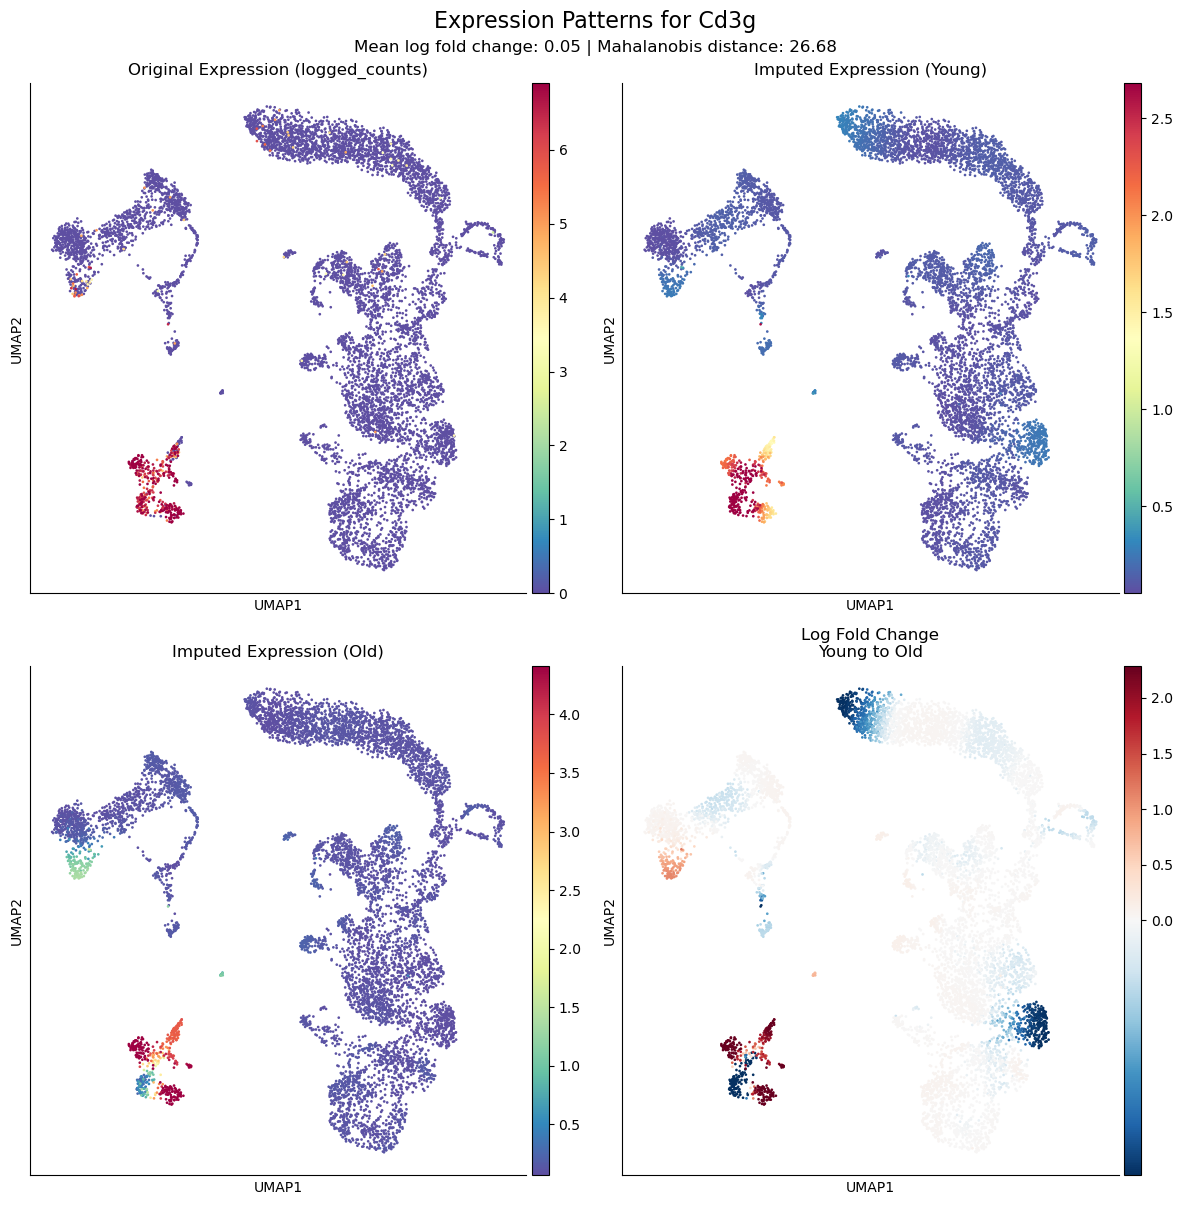

In [19]:
kompot.plot.plot_gene_expression(adata, gene="Cd3g", vmin="p2", vmax="p98")

## Conclusion: Impact of Sample Variance

After comparing both approaches, several key insights emerge:

1. **Reduced false positives**: Sample variance correction typically reduces the number of statistically significant findings, particularly for genes with high variability between samples.

2. **More robust biomarkers**: Genes that remain significant after sample variance correction are more likely to represent robust biological differences between conditions rather than sample-specific effects.

3. **Unchanged effect sizes**: Note that the log fold changes themselves remain similar with both methods; it's the statistical significance (p-values) that changes.

4. **Cell type specificity**: Some cell types show more consistent changes across samples than others, which becomes apparent when using sample variance correction.

For experiments with multiple biological replicates per condition, we strongly recommend using the sample variance correction approach to avoid inflated significance estimates and to identify the most robust biological signals.